In [1]:
import torch
import torch.nn as nn
import tomllib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm
import sys
sys.path.append("..")
from dataset import get_dataloaders

In [2]:
def set_seed(seed=313):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


DEVICE = 'cuda'

CONFIG_PATH = Path.cwd().parent / "config.toml"
with open(CONFIG_PATH, "rb") as f:
    cfg = tomllib.load(f)


In [3]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256), # 784->256
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256,32), # 256->32
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        self.latent_layer = nn.Sequential(
            nn.Linear(32,2), # 32->2
        )

        self.decoder = nn.Sequential(
            nn.Linear(2,32), # 2->32
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32,256), # 32->256
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 784), # 256->784
            nn.Sigmoid(),
        )

    def dec_forward(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        latent = self.latent_layer(encoded)
        reconstructed = self.decoder(latent)

        return encoded, latent, reconstructed


In [4]:

set_seed()
g = torch.Generator()
g.manual_seed(313)

In [5]:
model = AutoEncoder()
# model

In [6]:
sample = torch.randn(1,28,28)

In [7]:
model.eval()
with torch.no_grad():
    enc, lat, rec = model(sample)

In [8]:
enc.shape, lat.shape, rec.shape

(torch.Size([1, 32]), torch.Size([1, 2]), torch.Size([1, 784]))

In [9]:
train_loader = get_dataloaders("train",gen=g)

Loading MNIST datasets...
Train: 60000 samples, 937 batches
Val:   5000 samples, 79 batches
Test:  5000 samples, 79 batches


In [10]:
model = model.to(DEVICE)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

latent_history = dict()

for epoch in tqdm(range(cfg['training']['num_epochs'])):    
    
    lat_data = []
    lat_label = []

    for x, label in train_loader:
        x = x.to(DEVICE)
        opt.zero_grad()
        enc, lat, rec = model(x)
        loss = loss_fn(rec, x.view(x.size(0),-1))
        loss.backward()
        opt.step()

        lat_data.extend(lat.detach().cpu().numpy())
        lat_label.extend(label.numpy())
    
    latent_history[epoch] = (np.array(lat_data),np.array(lat_label))

100%|██████████| 100/100 [02:49<00:00,  1.70s/it]


In [11]:
# Create output folder
output_folder = '../latent_plots'
os.makedirs(output_folder, exist_ok=True)

# Compute global axis limits across all epochs
all_latents = np.vstack([h[0] for h in latent_history.values()])
x_min, x_max = all_latents[:, 0].min(), all_latents[:, 0].max()
y_min, y_max = all_latents[:, 1].min(), all_latents[:, 1].max()

# Add some padding (5%)
padding = 0.05
x_range = x_max - x_min
y_range = y_max - y_min
xlim = (x_min - padding * x_range, x_max + padding * x_range)
ylim = (y_min - padding * y_range, y_max + padding * y_range)

# Save plot for each epoch
for epoch, (latent_data, latent_labels) in latent_history.items():
    plt.figure(figsize=(10, 8))
    
    for digit in range(10):
        mask = latent_labels == digit
        plt.scatter(
            latent_data[mask, 0],
            latent_data[mask, 1],
            label=str(digit),
            alpha=0.6,
            s=5
        )
    
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.legend(title='Digit', markerscale=3)
    plt.xlabel('Latent Dim 1')
    plt.ylabel('Latent Dim 2')
    plt.title(f'Latent Space - Epoch {epoch}')
    
    plt.savefig(f'{output_folder}/epoch_{epoch:03d}.png', dpi=150, bbox_inches='tight')
    plt.close()


In [12]:
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        if hasattr(obj, 'tolist'):
            return obj.tolist()
        return super().default(obj)

with open('latent_history.json', 'w') as json_file:
    json.dump(latent_history, json_file, indent=4, cls=NumpyEncoder)

In [13]:
# sample random points in region: dim 1 region (-15,-5) and dim 2 region (-10,0)
num_samples = 10
sampled_latent_points = np.random.uniform(low=[-15, -10], high=[-5, 0],size=(num_samples,2))
sampled_latent_points.shape

(10, 2)

In [14]:
sampled_latent = torch.tensor(sampled_latent_points,dtype=torch.float32).to(DEVICE)
model = model.to(DEVICE)
model.eval()
with torch.no_grad():
    rec_sampled_latent_data = model.dec_forward(sampled_latent)
    rec_sampled_latent_data = rec_sampled_latent_data.detach().cpu().numpy()

In [15]:
rec_sampled_latent_data.shape

(10, 784)

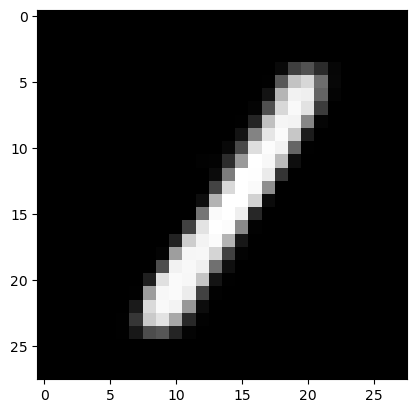

In [53]:
sample = random.choice(rec_sampled_latent_data)
plt.imshow(sample.reshape(28,-1),cmap='gray')

In [54]:
# overlapping region
# sample random points in region: dim 1 region (-15,-5) and dim 2 region (-10,0)
ovlp_num_samples = 10
ovlp_sampled_latent_points = np.random.uniform(low=[-5, -15], high=[10, 0],size=(num_samples,2))
ovlp_sampled_latent_points.shape

(10, 2)

In [55]:
ovlp_sampled_latent = torch.tensor(ovlp_sampled_latent_points,dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    ovlp_rec_sampled_latent_data = model.dec_forward(ovlp_sampled_latent)
    ovlp_rec_sampled_latent_data = ovlp_rec_sampled_latent_data.detach().cpu().numpy()

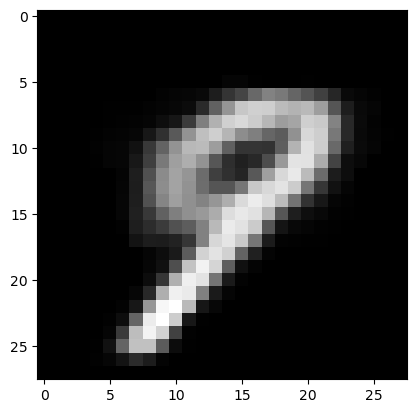

In [98]:
ovlp_sample = random.choice(ovlp_rec_sampled_latent_data)
plt.imshow(ovlp_sample.reshape(28,-1),cmap='gray')